# Automatic Differentiation - Baseline

We will start illustrating the use of **Automatic Differentiation** for some known simple functions using `pyTorch`.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [13]:
plt.style.use('dark_background')

# Automatic Differentiation by Example:

## Simple Function 1: $f(x)=\sin(x)$

In [82]:
x = torch.arange(0,2*np.pi,0.01)
x.requires_grad = True
x.grad

The gradient is `None` by default, that is why we do not get any output from the last cell.

Now, let us define the function we are interested in finding its derivative:

In [83]:
y = torch.sin(x)

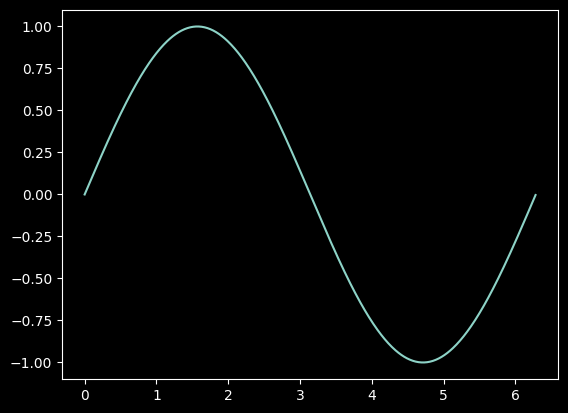

In [84]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy())
plt.show()

### Automatic Differentiation
Now, let us numerically compute the derivative of $y$ with respect to $x$, this is:
$$\dfrac{dy}{dx} = \cos(x)$$

In [85]:
# Essentially we compute the derivate for each point in the vector
for i in range(len(y)):
    y[i].backward(retain_graph=True)

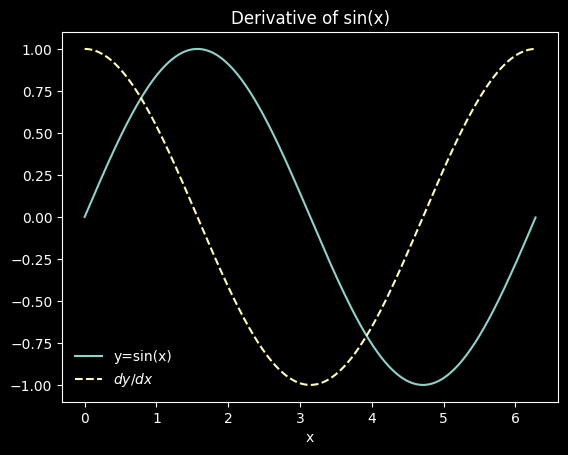

In [86]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy(), label='y=sin(x)')
ax.plot(x.detach().numpy(), x.grad.numpy(), label=r'$dy/dx$', linestyle='--')
ax.set_title('Derivative of sin(x)')
ax.set_xlabel('x')
ax.legend(loc='best', frameon=False)
plt.show()

So, we see that the autograd method works pretty well for this simple function

## (Not so) simple function 2: 
$$f(x)=((\log x^2)\sin(x))+ x^{-1}$$

In [231]:
def func2(x):
    """
    Compute the expression log(x**2) * sin(x) + x^(-1) using PyTorch operations.

    Parameters:
    ----------
    x : torch.Tensor
        A PyTorch tensor input.

    Returns:
    -------
    torch.Tensor
        The computed result as a PyTorch tensor.
    """
    return torch.log(x**2) * torch.sin(x) + torch.pow(x, -1)

In [232]:
x = torch.arange(-5, 5, 0.01, dtype=torch.float32)

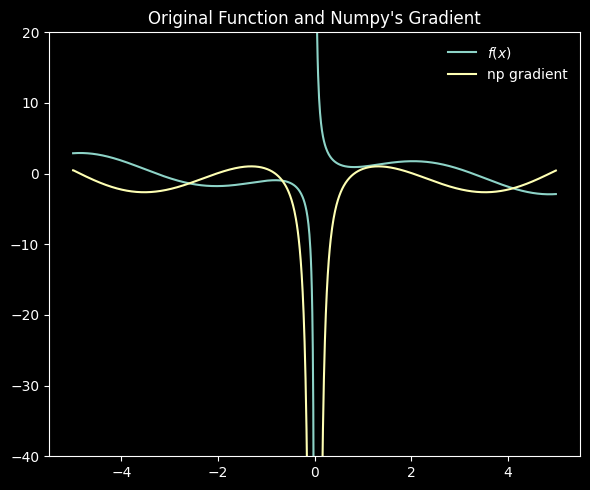

In [233]:
fig, ax = plt.subplots(dpi=100, figsize=(6,5))
ax.plot(x.detach().numpy(), func2(x).detach().numpy(), label=r'$f(x)$')
ax.plot(x.detach().numpy(), np.gradient(func2(x).detach().numpy(), x.detach().numpy()), label='np gradient')
ax.set_title("Original Function and Numpy's Gradient")
ax.legend(loc='best', frameon=False)
ax.set_ylim(-40, 20)
fig.tight_layout()
plt.show()

In [234]:
x = torch.arange(-5, 5, 0.01, dtype=torch.float32)
x.requires_grad = True
x.grad

In [235]:
y = func2(x)
y.backward(gradient=torch.ones(len(y)))

In [236]:
y.backward(gradient=torch.ones(len(y)))

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

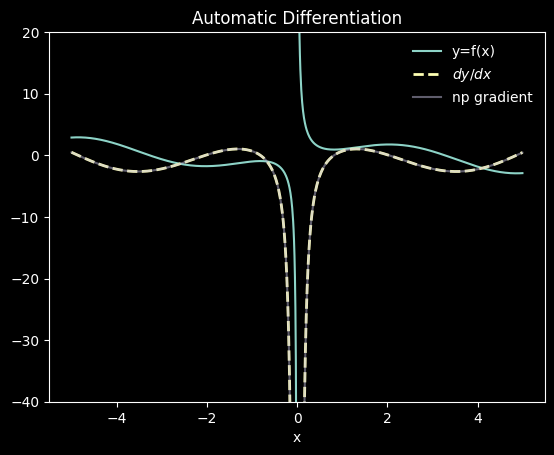

In [239]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy(), label='y=f(x)')
ax.plot(x.detach().numpy(), x.grad.numpy(), label=r'$dy/dx$', linestyle='--', lw=2)
ax.plot(x.detach().numpy(), np.gradient(func2(x).detach().numpy(), x.detach().numpy()), label='np gradient', alpha=0.5)
ax.set_title('Automatic Differentiation')
ax.set_xlabel('x')
ax.legend(loc='best', frameon=False)
ax.set_ylim(-40, 20)
plt.show()

# Random Noise Effect
Real life is harsh and full of noise. To have an idea of the effect of noise on the automatic differentiation procedure we will add a gaussian noise term to the data generation process and perform the autodiff estimation on top of this noisy set of data points. 

## Simple function: `f(x)=sin(x)`

In [240]:
import torch

def generate_noisy_data(x, func, noise_std=0.1):
    """
    Generate data by applying a user-defined function to x and adding random noise.

    Parameters:
    ----------
    x : torch.Tensor
        A tensor of input values (real numbers).
    func : callable
        A Python function that takes a tensor as input and returns a tensor as output.
    noise_std : float, optional
        The standard deviation of the Gaussian noise to add. Default is 0.1.

    Returns:
    -------
    torch.Tensor
        The noisy output values.
    """
    # Apply the user-defined function
    y = func(x)
    
    # Generate random noise
    noise = torch.randn_like(x) * noise_std
    
    # Add noise to the function output
    y_noisy = y + noise
    
    return y_noisy


In [251]:
x = torch.arange(0,2*np.pi,0.01)
x.requires_grad = True
x.grad
y = generate_noisy_data(x, torch.sin, 0.3)

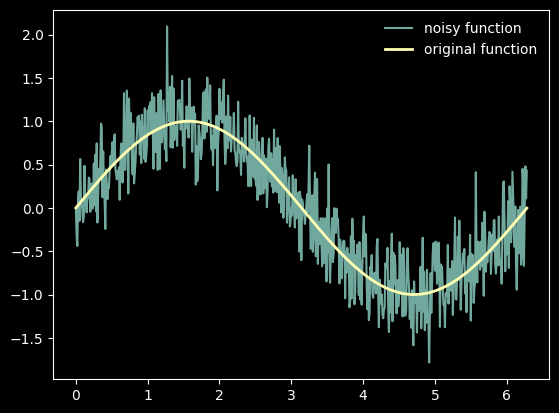

In [252]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy(), label="noisy function", alpha=0.8)
ax.plot(x.detach().numpy(), torch.sin(x).detach().numpy(), label="original function", lw=2)
ax.legend(loc="best", frameon=False)
plt.show()

In [253]:
y.backward(gradient=torch.ones(len(y)))

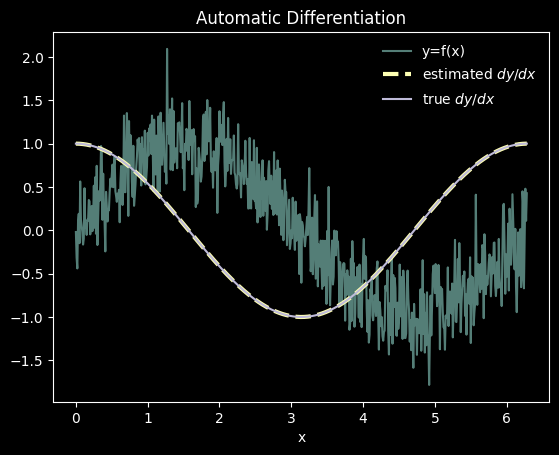

In [254]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(), y.detach().numpy(), label='y=f(x)', alpha=0.6)
ax.plot(x.detach().numpy(), x.grad.numpy(), label=r'estimated $dy/dx$', linestyle='--', lw=3)
# ax.plot(x.detach().numpy(), np.gradient(torch.sin(x).detach().numpy(), x.detach().numpy()), label='np gradient')
ax.plot(x.detach().numpy(), torch.cos(x).detach().numpy(), label=r'true $dy/dx$', linestyle='-')
ax.set_title('Automatic Differentiation')
ax.set_xlabel('x')
ax.legend(loc='best', frameon=False)
plt.show()

So, it appears that the autodiff is somewhat robust. To further investigate the effect of noise we could change the noise distribution parameters as well as the distribution itself.